## Gradio Pets

In [ ]:
!pip install -Uqq fastai

     |████████████████████████████████| 197 kB 30.1 MB/s 
     |████████████████████████████████| 60 kB 7.6 MB/s 


In [1]:
from fastai.vision.all import *

def is_cat(x): return x[0].isupper()

In [2]:
path = untar_data(URLs.PETS)/'images'

dls = ImageDataLoaders.from_name_func('.',
    get_image_files(path), valid_pct=0.2, seed=42,
    label_func=is_cat,
    item_tfms=Resize(192))

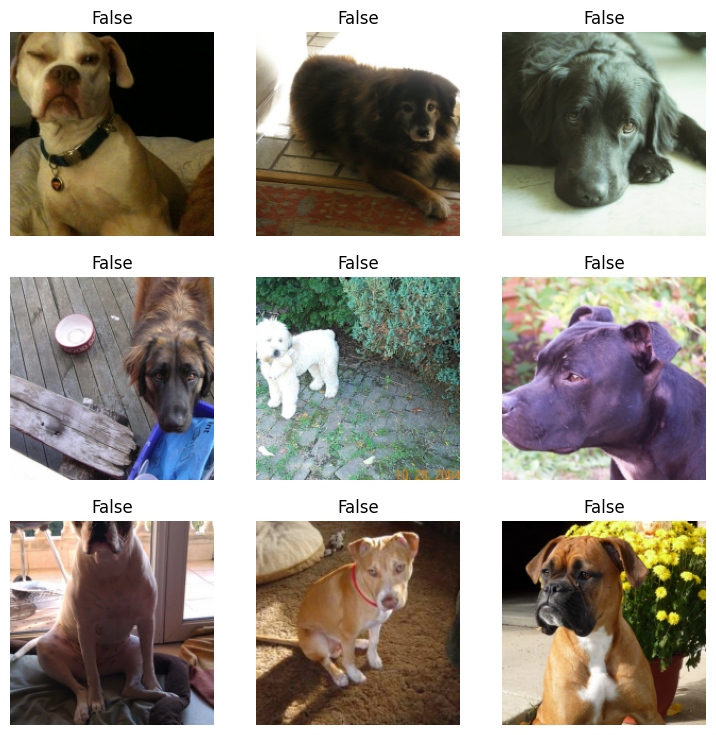

In [3]:
dls.show_batch()

In [4]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:02<00:00, 21.1MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,0.185974,0.038045,0.012179,00:47


epoch,train_loss,valid_loss,error_rate,time
0,0.070083,0.047085,0.014208,00:39
1,0.042258,0.026250,0.006766,00:39
2,0.026419,0.020729,0.006766,00:39


In [5]:
learn.export('model.pkl')